In [1]:
using ArgParse
using Dates
using JLD2
using Printf

using StatsBase
using Graphs
using SimpleWeightedGraphs
# using BlossomV
using GraphsMatching


const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

basic_correct (generic function with 1 method)

In [2]:
using Plots

In [3]:
function adv_MWPM_sample(L::Int, T::Int, p::Float64, peff::Float64, q::Float64)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        ρ = correct(ρ, peff, q)
        Ms[t+1] = magnetization(ρ)
    end

    return Ms
end

adv_MWPM_sample (generic function with 2 methods)

In [4]:
function correct(ρ::AbstractMatrix, peff::Float64, q::Float64)
    checks = measure(ρ, q)
    
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain
end

correct (generic function with 1 method)

In [5]:
function detect_charges(horizontal_checks::AbstractMatrix, vertical_checks::AbstractMatrix)
    L = size(vertical_checks)[1]
    sites = vertical_checks .⊻ horizontal_checks .⊻ circshift(vertical_checks,(-1,0)) .⊻ circshift(horizontal_checks,(0,-1))
    return [(j,i) for i in 1:L, j in 1:L][Bool.(sites)]
end

prob_weight(x::Float64) = -log(x/(1-x))
weight(peff::Float64, q::Float64, m::Bool) = q > 0 ? ((-1)^m * prob_weight(peff) + prob_weight(q)) : (m == true ? 0.0 : Inf)

site(L,x,y) = L*(mod1(y,L)-1)+mod1(x,L)
unsite(L,s) = (mod1(s,L), div(s-1,L)+1)

function build_matching_graph(checks::Tuple, peff::Float64, q::Float64)
    horizontal_checks, vertical_checks = checks
    L = size(horizontal_checks)[1]
    
    sources = [site(L,x,y) for y in 1:L for x in 1:L]
    horizontal_destinations = [site(L,x+1,y) for y in 1:L for x in 1:L]
    vertical_destinations = [site(L,x,y+1) for y in 1:L for x in 1:L]
    
    horizontal_weights = weight.(peff, q, Bool.(horizontal_checks))
    horizontal_weights[end,:] .= 0
    horizontal_weights = reshape(circshift(horizontal_weights,(0,-1))', L^2, 1)[:,1]

    vertical_weights = weight.(peff, q, Bool.(vertical_checks))
    vertical_weights[:,end] .= 0
    vertical_weights = reshape(circshift(vertical_weights,(-1,0))', L^2, 1)[:,1]
    
    return SimpleWeightedGraph([sources; sources], [horizontal_destinations; vertical_destinations], [horizontal_weights; vertical_weights])
end

function match_charges(fw::Graphs.FloydWarshallState, charges::Vector, L::Int; depth=50)
    subgraph = complete_graph(length(charges))
    weights = Dict{Edge,Float64}()
    for i in 1:length(charges)-1
        for j in i+1:length(charges)
            # if fw.dists[charges[i],charges[j]] < Inf
                weights[Edge(i, j)] = fw.dists[site(L,charges[i]...),site(L,charges[j]...)]
            # end
        end
    end

    match = minimum_weight_perfect_matching(subgraph, weights, depth)
    return match
end

function boundary_filter(checks::Tuple)
    horizontal_checks, vertical_checks = deepcopy(checks)
    L = size(horizontal_checks)[1]
    
    horizontal_checks[end,:] .= false
    vertical_checks[:,end] .= false
    
    return horizontal_checks, vertical_checks
end

cyclicmax(L, a, b) = mod(a-b-1, L) == 0 ? a : b 


function heal(checks::Tuple, peff::Float64, q::Float64)
    t1 = time()
    horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
    L = size(horizontal_checks)[1]
    charges = detect_charges(horizontal_checks, vertical_checks)

    # println(charges)

    if length(charges) == 0
        return horizontal_checks, vertical_checks
    end
    
    g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)
    fw = floyd_warshall_shortest_paths(g)
    match = match_charges(fw, charges, L)


    t2 = time()

    horizontal_checks, vertical_checks = apply_paths((horizontal_checks, vertical_checks), fw, match, charges, L)

    # println("Matching took $(t2 - t1) seconds.")
    # println("Pathing took $(time() - t2) seconds.")

    return horizontal_checks, vertical_checks
end

function apply_paths(checks::Tuple, fw::Graphs.FloydWarshallState, match::MatchingResult, charges::Vector, L::Int)
    horizontal_checks, vertical_checks = checks
    mated = Int[]
    

    for i in 1:length(charges)
        j = match.mate[i]
        if j in mated
            continue
        end

        # while loop path backwards
        
        s0 = site(L, charges[i]...)
        s2 = site(L, charges[j]...)
        while s0 != s2
            s1 = fw.parents[s0, s2]
            x1, y1 = unsite(L, s1)
            x2, y2 = unsite(L, s2)
            if x1 == x2
                vertical_checks[cyclicmax(L, y1, y2), x1] ⊻= true
            elseif y1 == y2
                horizontal_checks[y1, cyclicmax(L, x1, x2)] ⊻= true
            end

            s2 = s1
        end

        push!(mated, i)
        push!(mated, j)
    end
    return horizontal_checks, vertical_checks
end

apply_paths (generic function with 1 method)

In [6]:
data = Dict{Tuple{Int, Float64, Float64, Float64}, Vector{Float64}}()

Dict{Tuple{Int64, Float64, Float64, Float64}, Vector{Float64}}()

In [7]:
samples = 1

for p in 0.0:0.02:0.3
    for q in 0.0:0.02:0.3
        peff = q
        for L in [8]
            T = 2L

            M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
            data[(L, p, q, peff)] = M1s
        end
    end
end

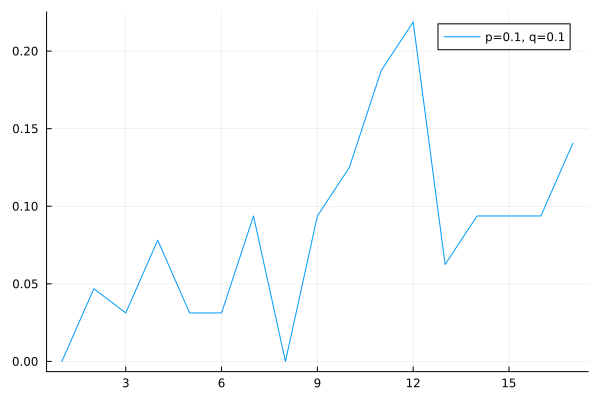

In [8]:
plot(data[(8, 0.1, 0.1, 0.1)], label="p=0.1, q=0.1")

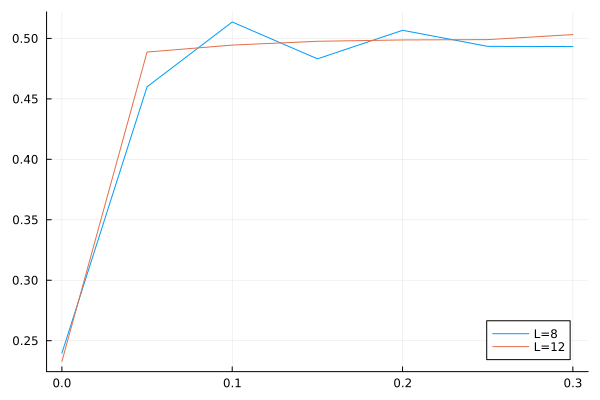

In [41]:
q = 0.3
plt = plot()

for L in [8, 12]
    ps = 0.0:0.05:0.3
    M1s = [data[(L, p, q, q)][end] for p in ps]
    plot!(plt, ps, M1s, label="L=$L")
end
plt

In [ ]:
L = 8
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 100
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

# each job can be 10L & 10k samples

([0.0, 0.369375, 0.4428125, 0.49671875, 0.52734375, 0.5009375, 0.47671875, 0.4871875, 0.48609375, 0.4790625, 0.5025, 0.4959375, 0.5140625, 0.5190625, 0.52765625, 0.50265625, 0.49078125], [0.0, 0.154990234375, 0.229345703125, 0.29035400390625, 0.31264404296875, 0.2945068359375, 0.27453857421875, 0.2723828125, 0.28670166015625, 0.2672314453125, 0.2889892578125, 0.296220703125, 0.302314453125, 0.322001953125, 0.32752197265625, 0.29644287109375, 0.29166259765625])

In [ ]:
L = 16
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 10
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
# each job can be 10L & 10k samples

([0.0, 0.387109375, 0.467578125, 0.502734375, 0.5109375, 0.4671875, 0.512109375, 0.52890625, 0.505078125, 0.468359375  …  0.46796875, 0.496875, 0.506640625, 0.4375, 0.458203125, 0.45703125, 0.490234375, 0.517578125, 0.451171875, 0.49453125], [0.0, 0.16203460693359376, 0.23256378173828124, 0.27119903564453124, 0.299212646484375, 0.236236572265625, 0.26815643310546877, 0.28740234375, 0.25940093994140623, 0.22996978759765624  …  0.232098388671875, 0.2661956787109375, 0.26526947021484376, 0.1983428955078125, 0.22305755615234374, 0.219500732421875, 0.25511932373046875, 0.27750396728515625, 0.21435699462890626, 0.2560791015625])

In [ ]:
L = 24
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 10
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
# each job can be 10L & 1k samples

([0.0, 0.4335069444444445, 0.4677083333333334, 0.46215277777777775, 0.5003472222222222, 0.5446180555555555, 0.47517361111111106, 0.44045138888888885, 0.4442708333333333, 0.4767361111111111  …  0.5362847222222221, 0.5144097222222223, 0.4722222222222222, 0.4690972222222222, 0.5218749999999999, 0.48315972222222214, 0.4859375, 0.5104166666666667, 0.4838541666666667, 0.5144097222222224], [0.0, 0.1929961781442901, 0.22284131462191356, 0.2192220052083333, 0.25856782889660496, 0.3000569661458333, 0.23491843894675926, 0.1982623818479938, 0.19977303964120371, 0.23271243248456788  …  0.29093092930169756, 0.2749653380594136, 0.22817563657407405, 0.2238329475308642, 0.27715145158179016, 0.23953179253472223, 0.24205397617669755, 0.2689037181712963, 0.2417519651813272, 0.27313337914737656])

In [ ]:
L = 32
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 1
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
# each job can be 10L & 200 samples

([0.0, 0.4248046875, 0.5107421875, 0.5087890625, 0.458984375, 0.390625, 0.4765625, 0.6103515625, 0.4423828125, 0.642578125  …  0.4765625, 0.5244140625, 0.6669921875, 0.421875, 0.4296875, 0.525390625, 0.3837890625, 0.5625, 0.486328125, 0.515625], [0.0, 0.18045902252197266, 0.26085758209228516, 0.2588663101196289, 0.21066665649414062, 0.152587890625, 0.22711181640625, 0.3725290298461914, 0.19570255279541016, 0.4129066467285156  …  0.22711181640625, 0.2750101089477539, 0.44487857818603516, 0.177978515625, 0.18463134765625, 0.2760353088378906, 0.1472940444946289, 0.31640625, 0.23651504516601562, 0.265869140625])

In [50]:
L = 40
p = 0.3
q = 0.2
peff = 0.5
T = 2L
samples = 1
M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)

([0.0, 0.420625, 0.449375, 0.543125, 0.470625, 0.514375, 0.44375, 0.5025, 0.541875, 0.528125  …  0.451875, 0.446875, 0.466875, 0.49125, 0.49875, 0.415625, 0.503125, 0.514375, 0.591875, 0.53], [0.0, 0.176925390625, 0.20193789062500003, 0.294984765625, 0.22148789062500002, 0.264581640625, 0.1969140625, 0.25250624999999993, 0.293628515625, 0.27891601562499996  …  0.20419101562500003, 0.199697265625, 0.217972265625, 0.2413265625, 0.24875156250000002, 0.17274414062500001, 0.25313476562500004, 0.264581640625, 0.35031601562500003, 0.28090000000000004])

In [1]:
using JLD2

In [5]:
path = "../output/collated_results.jld2"
data = load(path)["results"]

Dict{NTuple{6, Any}, Tuple{Vector, Vector, Int64, Float64}} with 2124 entries:
  ("adv_MWPM", 4, 4, 0.05,… => ([0.0, 0.0344678, 0.0487441, 0.0580966, 0.066986…
  ("adv_MWPM", 8, 8, 0.05,… => ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], …
  ("adv_MWPM", 12, 12, 0.0… => ([0.0, 0.0217361, 0.030191, 0.0326215, 0.0337847…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.00506445, 0.00549414, 0.00576367, 0.005…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0328398, 0.0515938, 0.0612148, 0.067709…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0580469, 0.110393, 0.148473, 0.176557, …
  ("adv_MWPM", 4, 4, 0.05,… => ([0.0, 0.0100434, 0.0120609, 0.0128491, 0.013395…
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.013791, 0.0165137, 0.0175078, 0.0176973…
  ("adv_MWPM", 8, 8, 0.05,… => ([0.0, 0.0671641, 0.111191, 0.141182, 0.166275, …
  ("adv_MWPM", 12, 12, 0.0… => ([0.0, 0.0758194, 0.140712, 0.192868, 0.241851, …
  ("adv_MWPM", 16, 16, 0.0… => ([0.0, 0.0258672, 0.0388262, 0.0471465, 0.051570…
  ("adv_MWPM", 12, 12, 0.0… =>

In [6]:
p = 0.2

plt = plot()

Ls = unique([key[2] for key in keys(data) if key[4] == p])
for L in Ls
    Ts = unique([key[3] for key in keys(data) if key[4] == p && key[2] == L])
    for T in Ts[1:end]
        peffs = unique([key[6] for key in keys(data) if key[4] == p && key[2] == L && key[3] == T])
        for peff in peffs[1:2]
            qs = unique([key[5] for key in keys(data) if key[4] == p && key[2] == L && key[3] == T && key[6] == peff])
            println(sort(qs))
            Ms = [data[("adv_MWPM", L, T, p, q, peff)][1][end] for q in qs]
            plot!(plt, qs, Ms, label="L=$L, T=$T, peff=$peff")
        end
    end
end
plt

InterruptException: InterruptException:

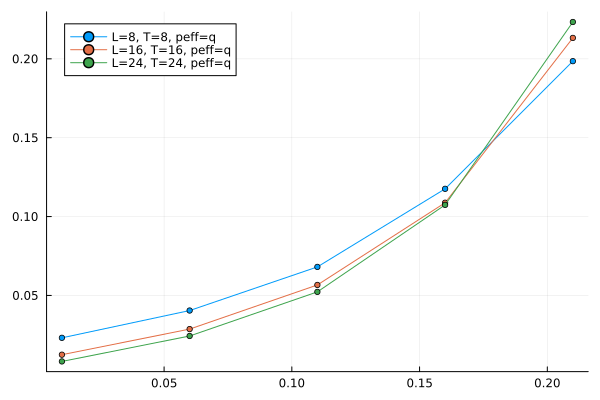

In [7]:
p = 0.05
plt = plot()
for L in 8:8:24
    T = L

    # peffs = sort(unique([key[6] for key in keys(data) if key[1] == "adv_MWPM" && key[2] == L && key[3] == T && key[4] == p]))
    # println(peffs)
    qs = 0.01:0.05:0.25
    Ms = [data[("adv_MWPM", L, T, p, q, q)][1][end] for q in qs]
    plot!(plt, qs, Ms, label="L=$L, T=$T, peff=q", m=3)
end
plt

In [9]:
# ML

unique([(key[2], key[3], data[key][3]) for key in keys(data) if key[1] == "adv_MWPM"])

18-element Vector{Tuple{Int64, Int64, Int64}}:
 (4, 4, 200000)
 (8, 8, 20000)
 (12, 12, 2000)
 (16, 16, 2000)
 (16, 16, 4000)
 (16, 16, 1000)
 (24, 24, 2000)
 (20, 20, 2000)
 (12, 12, 4000)
 (4, 4, 300000)
 (8, 8, 30000)
 (8, 80, 50000)
 (24, 240, 499)
 (16, 160, 500)
 (16, 160, 490)
 (24, 240, 501)
 (24, 240, 500)
 (24, 24, 2020)

In [ ]:
using Plots

In [ ]:
L = 104
T = 20L
p = 0.1
q = 0.1
samples = 10
M1s, M2s = MV_sample(L, T, p, q, samples) 

In [ ]:
plot(mean.(M1s))

In [ ]:
# data = load("../sample_algo=MV_L=8_T=16_p=0p050_q=0p100_samples=10_20260224_052232_3250195359.jld2")
# data

In [ ]:
# using GraphsMatching

In [ ]:
# data = Dict{Tuple{Int, Float64, Float64, Float64}, Vector{Float64}}()

In [ ]:
samples = 1

for p in 0.0:0.01:0.3
    for q in 0.0:0.01:0.2
        peff = q
        for L in [8]#, 16]
            T = 2L

            M1s, _ = adv_MWPM_sample(L, T, p, peff, q, samples)
            data[(L, p, q, peff)] = M1s
        end
    end
end

In [ ]:
L = 12
p = 0.2
q = 0.05
peff = q
T = 2L
samples = 100

M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)

In [ ]:
plot(M1s)

In [ ]:
L = 8
p = 0.3
q = 0.15
peff = 0.45
T = 2L
samples = 10000

M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)

plot(M1s, label="L=8")

L = 12
M1s, M2s = adv_MWPM_sample(L, T, p, peff, q, samples)
plot!(M1s, label="L=12")

In [ ]:
plot(M1s)

In [ ]:
L = 20
p = 0.1
q = 0.1
peff = 0.15
T = 1

ρ = initialstate(L)
Ms = zeros(Float64, T+1)

for t in 1:T
    ρ = noiselayer(ρ, p)

    checks = measure(ρ, q)
    
    t0 = time()
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    println("Healing took $(time() - t0) seconds.")

    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    ρ = ρ .⊻ domain

    Ms[t+1] = magnetization(ρ)
end



In [ ]:
L = 20
p = 0.3
q = 0.1
peff = 0.5
T = 2L

ρ = initialstate(L)
Ms = zeros(Float64, T+1)

for t in 1:T
    ρ = noiselayer(ρ, p)

    ρ = correct(ρ, peff, q)

    Ms[t+1] = magnetization(ρ)
end



In [ ]:
plot(Ms)

In [ ]:
L = 40
p = 0.1
q = 0.15
peff = 0.2
ρ  = initialstate(L)
ρ = noiselayer(ρ, p)

checks = measure(ρ, q)

horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
L = size(horizontal_checks)[1]
charges = detect_charges(horizontal_checks, vertical_checks)

# println(charges)

if length(charges) == 0
    return horizontal_checks, vertical_checks
end

g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)

t1 = time()
fw = floyd_warshall_shortest_paths(g)
t2 = time()
match = match_charges(fw, charges, L)
t3 = time()

println("Floyd-Warshall time: ", t2 - t1)
println("Matching time: ", t3 - t2)

In [ ]:
fw.parents[1, 20]

In [ ]:
using PyQDecoders
using PyQDecoders: sps, np, pm

In [ ]:
function adv_MWPM_sample(L::Int, T::Int, p::Float64, peff::Float64, q::Float64)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        ρ = correct(ρ, peff, q)
        Ms[t+1] = magnetization(ρ)
    end

    return Ms
end

In [ ]:
function correct(ρ::AbstractMatrix, peff::Float64, q::Float64)
    checks = measure(ρ, q)
    
    horizontal_checks, vertical_checks = heal(checks, peff, q)
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain
end

In [ ]:
function detect_charges(horizontal_checks::AbstractMatrix, vertical_checks::AbstractMatrix)
    L = size(vertical_checks)[1]
    sites = vertical_checks .⊻ horizontal_checks .⊻ circshift(vertical_checks,(-1,0)) .⊻ circshift(horizontal_checks,(0,-1))
    return [(j,i) for i in 1:L, j in 1:L][Bool.(sites)]
end

prob_weight(x::Float64) = -log(x/(1-x))
weight(peff::Float64, q::Float64, m::Bool) = (-1)^m * prob_weight(peff) + prob_weight(q)

site(L,x,y) = L*(mod1(y,L)-1)+mod1(x,L)
unsite(L,s) = (mod1(s,L), div(s-1,L)+1)

function build_matching_graph(checks::Tuple, peff::Float64, q::Float64)
    horizontal_checks, vertical_checks = checks
    L = size(horizontal_checks)[1]
    
    sources = [site(L,x,y) for y in 1:L for x in 1:L]
    horizontal_destinations = [site(L,x+1,y) for y in 1:L for x in 1:L]
    vertical_destinations = [site(L,x,y+1) for y in 1:L for x in 1:L]
    
    horizontal_weights = weight.(peff, q, Bool.(horizontal_checks))
    horizontal_weights[end,:] .= 0
    horizontal_weights = reshape(circshift(horizontal_weights,(0,-1))', L^2, 1)[:,1]

    vertical_weights = weight.(peff, q, Bool.(vertical_checks))
    vertical_weights[:,end] .= 0
    vertical_weights = reshape(circshift(vertical_weights,(-1,0))', L^2, 1)[:,1]
    
    return SimpleWeightedGraph([sources; sources], [horizontal_destinations; vertical_destinations], [horizontal_weights; vertical_weights])
end

function match_charges(fw::Graphs.FloydWarshallState, charges::Vector, L::Int; depth=50)
    subgraph = complete_graph(length(charges))
    weights = Dict{Edge,Float64}()
    for i in 1:length(charges)-1
        for j in i+1:length(charges)
            # if fw.dists[charges[i],charges[j]] < Inf
                weights[Edge(i, j)] = fw.dists[site(L,charges[i]...),site(L,charges[j]...)]
            # end
        end
    end

    match = minimum_weight_perfect_matching(subgraph, weights, depth)
    return match
end

function boundary_filter(checks::Tuple)
    horizontal_checks, vertical_checks = deepcopy(checks)
    L = size(horizontal_checks)[1]
    
    horizontal_checks[end,:] .= false
    vertical_checks[:,end] .= false
    
    return horizontal_checks, vertical_checks
end

cyclicmax(L, a, b) = mod(a-b-1, L) == 0 ? a : b 


function heal(checks::Tuple, peff::Float64, q::Float64)
    t1 = time()
    horizontal_checks, vertical_checks = deepcopy(boundary_filter(checks))
    L = size(horizontal_checks)[1]
    charges = detect_charges(horizontal_checks, vertical_checks)

    # println(charges)

    if length(charges) == 0
        return horizontal_checks, vertical_checks
    end
    
    g = build_matching_graph((horizontal_checks, vertical_checks), peff, q)
    fw = floyd_warshall_shortest_paths(g)
    match = match_charges(fw, charges, L)


    t2 = time()

    horizontal_checkes, vertical_checks = apply_paths((horizontal_checks, vertical_checks), fw, match, charges, L)

    # println("Matching took $(t2 - t1) seconds.")
    # println("Pathing took $(time() - t2) seconds.")

    return horizontal_checks, vertical_checks
end

function apply_paths(checks::Tuple, fw::Graphs.FloydWarshallState, match::MatchingResult, charges::Vector, L::Int)
    horizontal_checks, vertical_checks = checks
    mated = Int[]

    for i in 1:length(charges)
        j = match.mate[i]
        if j in mated
            continue
        end

        # while loop path backwards
        
        s0 = site(L, charges[i]...)
        s2 = site(L, charges[j]...)
        while s0 != s2
            s1 = fw.parents[s0, s2]
            x1, y1 = unsite(L, s1)
            x2, y2 = unsite(L, s2)
            if x1 == x2
                vertical_checks[cyclicmax(L, y1, y2), x1] ⊻= true
            elseif y1 == y2
                horizontal_checks[y1, cyclicmax(L, x1, x2)] ⊻= true
            end

            s2 = s1
        end

        push!(mated, i)
        push!(mated, j)
    end
    return horizontal_checks, vertical_checks
end